# SepAware Replicated $2^k r$ Factorial Experiment with ANOVA Diagnostics

This local, VS Code–ready notebook reruns the SepAware $2^2$ factorial experiment
with $r=5$ stratified folds and adds formal replicated-factorial inference.

It reports the actual fold-level responses, raw- and log-scale effects, ANOVA sums
of squares, percentage variation due to separability, anchor, interaction and
experimental error, pairwise correlation-percentage tables, residual QQ plots,
and homoscedasticity/normality diagnostics.

> **Runtime warning:** the complete experiment trains CTGAN repeatedly and can take
> hours. Start with `SMOKE_TEST = True`; use `False` for the defensible full run.


## 1. Setup

Run this cell in Google Colab. If you are running locally and already have the packages, you may skip installation.

In [1]:
print('Using pinned dependencies from the local experiment environment.')

Using pinned dependencies from the local experiment environment.


## 2. Imports and Configuration

In [2]:
import os
import random
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd

from scipy.spatial.distance import cdist
from scipy.stats import wasserstein_distance, t

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    silhouette_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer

from catboost import CatBoostClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Full design requested by the methodology:
N_FOLDS = 5

# Set True only for a fast structural check; False runs the requested experiment.
SMOKE_TEST = False
CTGAN_EPOCHS = 5 if SMOKE_TEST else 100
CANDIDATE_POOL_MULTIPLIER = 5

# Factor levels for the 2^2 design.
SEP_LOW = 0.0
SEP_HIGH = 1.0
ANCHOR_LOW = 0.0
ANCHOR_HIGH = 0.5

FACTORIAL_CONDITIONS = [
    {"condition": "S0_A0_realism_only", "sep_on": 0, "anchor_on": 0, "lambda_sep": SEP_LOW, "lambda_anchor": ANCHOR_LOW},
    {"condition": "S1_A0_sep_only", "sep_on": 1, "anchor_on": 0, "lambda_sep": SEP_HIGH, "lambda_anchor": ANCHOR_LOW},
    {"condition": "S0_A1_anchor_only", "sep_on": 0, "anchor_on": 1, "lambda_sep": SEP_LOW, "lambda_anchor": ANCHOR_HIGH},
    {"condition": "S1_A1_sep_anchor", "sep_on": 1, "anchor_on": 1, "lambda_sep": SEP_HIGH, "lambda_anchor": ANCHOR_HIGH},
]

# Keep this off unless you want to store every selected synthetic fold dataset.
SAVE_SYNTHETIC_PER_FOLD = False

OUTPUT_DIR = Path("sepaware_factorial_cv_outputs")
TABLE_DIR = OUTPUT_DIR / "tables"
PLOT_DIR = OUTPUT_DIR / "plots"
SYNTH_DIR = OUTPUT_DIR / "synthetic_folds"
for d in [TABLE_DIR, PLOT_DIR, SYNTH_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR.resolve())
print("Conditions:")
display(pd.DataFrame(FACTORIAL_CONDITIONS))

Output directory: <SEPAWARE_DATA_ROOT>/sepaware_factorial_cv_outputs
Conditions:


,condition,sep_on,anchor_on,lambda_sep,lambda_anchor
0,S0_A0_realism_only,0,0,0.0,0.0
1,S1_A0_sep_only,1,0,1.0,0.0
2,S0_A1_anchor_only,0,1,0.0,0.5
3,S1_A1_sep_anchor,1,1,1.0,0.5


## 3. Dataset Definitions

In [3]:
COVID_FEATURES = [
    "idade", "sexo", "etilismo", "tabagismo",
    "motivo_cancer", "motivo_msk", "motivo_digestivo2", "motivo_cardio2",
    "motivo_procedimentos2", "motivo_lesao2", "motivo_respiratorio", "motivo_neuro",
    "motivo_pele", "motivo_genitourinaria", "motivo_dm", "motivo_mental_subst",
    "motivo_infec2", "motivo_propedeutica",
    "n_comorbidades", "comorb_hipertensao", "comorb_ic", "comorb_dac",
    "comorb_fibrilacao", "comorb_avc", "comorb_dpoc", "comorb_asma",
    "comorb_dm", "comorb_obesidade", "comorb_drc", "comorb_cancer",
    "comorb_reumatologica", "comorb_cirrose", "comorb_hiv",
]

COVID_ANCHORS = ["idade", "sexo", "tabagismo", "comorb_cirrose"]

VIGITEL_FEATURES = [
    "age", "sex", "fumante", "exfuma", "inativo", "ativo_livre", "ati_livre",
    "diab", "hart", "dislipidemia", "doces5", "lanche_7", "gordura", "flvreg",
    "years_schooling",
]

VIGITEL_ANCHORS = [
    "age", "sex", "fumante", "exfuma", "inativo", "ativo_livre", "ati_livre",
    "diab", "hart", "dislipidemia", "doces5", "lanche_7", "gordura", "flvreg",
    "years_schooling",
]

DATASET_CONFIGS = {
    "covid": {
        "path_candidates": [Path("/content/banco_covidIH.xlsx"), Path("banco_covidIH.xlsx")],
        "target": "obito",
        "target_candidates": ["obito"],
        "features": COVID_FEATURES,
        "anchors": COVID_ANCHORS,
        "file_type": "excel",
        "sample_n": None,
    },
    "vigitel": {
        "path_candidates": [Path("/content/vigitel2006_2023_obesidade_exclusoes.parquet"), Path("vigitel2006_2023_obesidade_exclusoes.parquet")],
        "target": "obesity",
        "target_candidates": ["obesity", "desfecho", "obesidade", "obeso"],
        "features": VIGITEL_FEATURES,
        "anchors": VIGITEL_ANCHORS,
        "file_type": "parquet",
        # Keep the experiment comparable with the previous notebook.
        "sample_n": 5000,
    },
}

RUN_DATASETS = ["covid", "vigitel"]

## 4. Loading and Preprocessing Helpers

In [4]:
def resolve_path(path_candidates):
    for p in path_candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"None of these paths exists: {path_candidates}")


def deterministic_sex_binary(s):
    # Deterministic sex encoder used for both datasets when sex is string-like.
    if pd.isna(s):
        return np.nan
    val = str(s).strip().lower()
    female_tokens = {"f", "fem", "feminino", "female", "mulher", "woman", "2"}
    male_tokens = {"m", "masc", "masculino", "male", "homem", "man", "1"}
    if val in female_tokens:
        return 1
    if val in male_tokens:
        return 0
    try:
        num = float(val)
        if num in [0, 1]:
            return int(num)
        if num == 2:
            return 1
    except Exception:
        pass
    return np.nan


def clean_binary_like(series):
    x = pd.to_numeric(series, errors="coerce")
    vals = set(x.dropna().unique())
    if vals.issubset({0, 1}):
        return x.round().clip(0, 1)
    # Many survey/clinical binary columns are coded as 1/2. Map the larger code to 1.
    if vals.issubset({1, 2}):
        return x.map({1: 0, 2: 1})
    return x


def load_dataset(config, dataset_name):
    path = resolve_path(config["path_candidates"])
    print(f"Loading {dataset_name} from {path}")
    if config["file_type"] == "excel":
        df = pd.read_excel(path)
    elif config["file_type"] == "parquet":
        df = pd.read_parquet(path)
    else:
        raise ValueError(config["file_type"])

    target = config["target"]
    target_candidates = config.get("target_candidates", [target])
    found_target = next((c for c in target_candidates if c in df.columns), None)
    if found_target is None:
        raise ValueError(
            f"None of the target candidates {target_candidates!r} were found. "
            f"Available columns include: {list(df.columns)[:20]}"
        )
    if found_target != target:
        df = df.rename(columns={found_target: target})
        print(f"{dataset_name}: renamed target column {found_target!r} to {target!r}.")

    features = [c for c in config["features"] if c in df.columns]
    missing = [c for c in config["features"] if c not in df.columns]
    if missing:
        print(f"{dataset_name}: skipping missing features:", missing)

    keep = features + [target]
    df = df[keep].copy()
    df = df.dropna(subset=[target])

    for sex_col in ["sexo", "sex"]:
        if sex_col in df.columns:
            if not pd.api.types.is_numeric_dtype(df[sex_col]):
                df[sex_col] = df[sex_col].map(deterministic_sex_binary)
            else:
                df[sex_col] = clean_binary_like(df[sex_col])

    for c in keep:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Target must be binary. If coded as 1/2, convert deterministically to 0/1.
    yvals = set(df[target].dropna().unique())
    if yvals.issubset({1, 2}):
        df[target] = df[target].map({1: 0, 2: 1})
    df[target] = pd.to_numeric(df[target], errors="coerce").round().clip(0, 1)
    df = df.dropna(subset=[target])
    df[target] = df[target].astype(int)

    # Feature handling.
    for c in features:
        if df[c].dropna().nunique() <= 2:
            df[c] = clean_binary_like(df[c])
            mode = df[c].mode(dropna=True)
            fill = mode.iloc[0] if len(mode) else 0
            df[c] = df[c].fillna(fill).round().clip(0, 1).astype(int)
        else:
            df[c] = df[c].fillna(df[c].median())

    sample_n = config.get("sample_n")
    if sample_n is not None and len(df) > sample_n:
        df = df.groupby(target, group_keys=False).apply(
            lambda g: g.sample(n=max(1, int(round(sample_n * len(g) / len(df)))), random_state=RANDOM_SEED)
        )
        if len(df) > sample_n:
            df = df.sample(n=sample_n, random_state=RANDOM_SEED)
        df = df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

    features = [c for c in features if c in df.columns]
    anchors = [a for a in config["anchors"] if a in df.columns]
    print(f"{dataset_name}: shape={df.shape}, target rate={df[target].mean():.3f}, features={len(features)}, anchors={anchors}")
    display(df[target].value_counts().rename("count").to_frame())
    return df.reset_index(drop=True), features, anchors, target

## 5. Shared SepAware, Evaluation, and Correlation Functions

In [5]:
def normalize01(x):
    x = np.asarray(x, dtype=float)
    ok = np.isfinite(x)
    out = np.zeros_like(x, dtype=float)
    if ok.sum() == 0:
        return out
    lo, hi = np.nanpercentile(x[ok], [1, 99])
    if hi <= lo:
        out[ok] = 0.5
    else:
        out[ok] = np.clip((x[ok] - lo) / (hi - lo), 0, 1)
    out[~ok] = np.nanmedian(out[ok]) if ok.any() else 0
    return out


def make_encoded_frame(df, features, target, reference_df=None):
    reference_df = df if reference_df is None else reference_df
    out = pd.DataFrame(index=df.index)
    for c in features:
        x = pd.to_numeric(df[c], errors="coerce")
        ref = pd.to_numeric(reference_df[c], errors="coerce") if c in reference_df.columns else x
        if ref.dropna().nunique() <= 2:
            mode = ref.mode(dropna=True)
            fill = mode.iloc[0] if len(mode) else 0
            out[c] = x.fillna(fill).round().clip(0, 1)
        else:
            out[c] = x.fillna(ref.median())
    out[target] = pd.to_numeric(df[target], errors="coerce").fillna(0).round().clip(0, 1).astype(int)
    return out


def scaled_matrix(df, features, target, reference_df):
    enc = make_encoded_frame(df, features, target, reference_df)
    ref = make_encoded_frame(reference_df, features, target, reference_df)
    scaler = StandardScaler().fit(ref[features])
    return scaler.transform(enc[features])


def make_metadata(df, features, target):
    metadata = SingleTableMetadata()
    metadata.detect_from_dataframe(df)
    for c in df.columns:
        try:
            sdtype = "categorical" if c == target or df[c].dropna().nunique() <= 2 else "numerical"
            metadata.update_column(c, sdtype=sdtype)
        except Exception:
            pass
    return metadata


def clean_synthetic(syn, reference, features, target):
    cols = [c for c in features + [target] if c in syn.columns]
    syn = syn[cols].copy()
    for c in features:
        ref = pd.to_numeric(reference[c], errors="coerce")
        x = pd.to_numeric(syn[c], errors="coerce")
        if ref.dropna().nunique() <= 2:
            allowed = sorted(ref.dropna().unique())
            mode = ref.mode(dropna=True)
            fill = mode.iloc[0] if len(mode) else 0
            x = x.fillna(fill).round()
            syn[c] = x.apply(lambda v: min(allowed, key=lambda a: abs(a - v)) if allowed else v).astype(int)
        else:
            syn[c] = x.fillna(ref.median()).clip(ref.quantile(0.001), ref.quantile(0.999))
    syn[target] = pd.to_numeric(syn[target], errors="coerce").fillna(reference[target].mode().iloc[0]).round().clip(0, 1).astype(int)
    return syn.reset_index(drop=True)


def train_ctgan(train_df, features, target, epochs=CTGAN_EPOCHS):
    metadata = make_metadata(train_df, features, target)
    try:
        synth = CTGANSynthesizer(metadata, epochs=epochs, verbose=False, cuda=False)
    except TypeError:
        synth = CTGANSynthesizer(metadata, epochs=epochs, verbose=False)
    synth.fit(train_df)
    return synth


def sample_ctgan(synth, n, reference, features, target):
    try:
        syn = synth.sample(num_rows=n)
    except TypeError:
        syn = synth.sample(n)
    return clean_synthetic(syn, reference, features, target)


def fit_selection_context(real_train, features, anchors, target):
    enc = make_encoded_frame(real_train, features, target, real_train)
    X = scaled_matrix(enc, features, target, real_train)
    y = enc[target].to_numpy().astype(int)
    ctx = {
        "real_train": real_train,
        "enc": enc,
        "X": X,
        "y": y,
        "nn_real": NearestNeighbors(n_neighbors=1).fit(X),
        "class_nn": {},
        "anchors": anchors,
        "anchor_stats": {},
    }
    for cls in [0, 1]:
        if (y == cls).any():
            ctx["class_nn"][cls] = NearestNeighbors(n_neighbors=1).fit(X[y == cls])

    clf = RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )
    clf.fit(enc[features], y)
    ctx["clf"] = clf

    for a in anchors:
        if a not in enc.columns:
            continue
        if enc[a].dropna().nunique() <= 2:
            ctx["anchor_stats"][a] = ("discrete", enc.groupby(a)[target].mean().to_dict())
        else:
            ctx["anchor_stats"][a] = ("continuous", enc.groupby(target)[a].agg(["mean", "std"]).to_dict("index"))
    return ctx


def score_candidates(pool, ctx, features, target):
    enc = make_encoded_frame(pool, features, target, ctx["real_train"])
    X = scaled_matrix(enc, features, target, ctx["real_train"])
    y = enc[target].to_numpy().astype(int)

    realism = 1 - normalize01(ctx["nn_real"].kneighbors(X, return_distance=True)[0].ravel())

    same = np.full(len(enc), np.nan)
    opp = np.full(len(enc), np.nan)
    for cls in [0, 1]:
        idx = np.where(y == cls)[0]
        if len(idx) and cls in ctx["class_nn"]:
            same[idx] = ctx["class_nn"][cls].kneighbors(X[idx], return_distance=True)[0].ravel()
        if len(idx) and (1 - cls) in ctx["class_nn"]:
            opp[idx] = ctx["class_nn"][1 - cls].kneighbors(X[idx], return_distance=True)[0].ravel()
    margin = opp - same
    proba = ctx["clf"].predict_proba(enc[features])
    conf = np.array([proba[i, int(y[i])] if int(y[i]) < proba.shape[1] else np.max(proba[i]) for i in range(len(y))])
    separability = 0.5 * normalize01(margin) + 0.5 * normalize01(conf)

    anchor_terms = []
    for a, (typ, stats) in ctx["anchor_stats"].items():
        vals = []
        if typ == "continuous":
            for _, row in enc.iterrows():
                st = stats.get(int(row[target]), {})
                mu, sd = st.get("mean", np.nan), st.get("std", np.nan)
                vals.append(np.exp(-abs(row[a] - mu) / sd) if np.isfinite(mu) and np.isfinite(sd) and sd > 0 else 0.5)
        else:
            for _, row in enc.iterrows():
                p = stats.get(row[a], np.nan)
                vals.append((p if int(row[target]) == 1 else 1 - p) if np.isfinite(p) else 0.5)
        anchor_terms.append(np.asarray(vals))
    anchor = normalize01(np.mean(anchor_terms, axis=0)) if anchor_terms else np.full(len(enc), 0.5)

    scored = pool.copy().reset_index(drop=True)
    scored["realism_score"] = realism
    scored["separability_score"] = separability
    scored["anchor_preservation_score"] = anchor
    return scored


def select_by_factor_score(scored, train_reference, features, target, lambda_sep, lambda_anchor):
    scored = scored.copy()
    scored["final_score"] = (
        scored["realism_score"]
        + lambda_sep * scored["separability_score"]
        + lambda_anchor * scored["anchor_preservation_score"]
    )
    desired = train_reference[target].value_counts().to_dict()
    parts = []
    for cls in [0, 1]:
        n = int(desired.get(cls, 0))
        part = scored[scored[target].astype(int) == cls].sort_values("final_score", ascending=False).head(n)
        parts.append(part)
    out = pd.concat(parts, axis=0)
    if len(out) < len(train_reference):
        remainder = scored.drop(index=out.index, errors="ignore").sort_values("final_score", ascending=False).head(len(train_reference) - len(out))
        out = pd.concat([out, remainder], axis=0)
    out = out.sort_values("final_score", ascending=False).head(len(train_reference))
    mean_scores = {
        "mean_selected_final_score": float(out["final_score"].mean()),
        "mean_selected_realism_score": float(out["realism_score"].mean()),
        "mean_selected_separability_score": float(out["separability_score"].mean()),
        "mean_selected_anchor_score": float(out["anchor_preservation_score"].mean()),
    }
    drop_cols = ["realism_score", "separability_score", "anchor_preservation_score", "final_score"]
    selected = clean_synthetic(out.drop(columns=[c for c in drop_cols if c in out.columns]), train_reference, features, target)
    return selected, mean_scores

In [6]:
def split_xy(train_df, test_df, features, target):
    train_enc = make_encoded_frame(train_df, features, target, train_df)
    test_enc = make_encoded_frame(test_df, features, target, train_df)
    X_train = train_enc[features]
    y_train = train_enc[target].astype(int)
    X_test = test_enc[features]
    y_test = test_enc[target].astype(int)
    imputer = SimpleImputer(strategy="median")
    X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=features)
    X_test = pd.DataFrame(imputer.transform(X_test), columns=features)
    return X_train, X_test, y_train, y_test


def get_models():
    return {
        "CatBoost": CatBoostClassifier(
            iterations=300,
            depth=4,
            learning_rate=0.05,
            loss_function="Logloss",
            eval_metric="F1",
            random_seed=RANDOM_SEED,
            verbose=False,
            allow_writing_files=False,
        ),
        "XGBoost": XGBClassifier(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_SEED,
            n_jobs=1,
            tree_method="hist",
        ),
    }


def evaluate_train_test(train_df, test_df, features, target, dataset_name, fold, dataset_group, evaluation):
    X_train, X_test, y_train, y_test = split_xy(train_df, test_df, features, target)
    rows = []
    for model_name, model in get_models().items():
        try:
            model.fit(X_train, y_train)
            pred = np.asarray(model.predict(X_test)).ravel().astype(int)
            score = None
            if hasattr(model, "predict_proba"):
                proba = model.predict_proba(X_test)
                score = proba[:, 1] if proba.shape[1] > 1 else proba.ravel()
            row = {
                "dataset_group": dataset_group,
                "fold": fold,
                "dataset": dataset_name,
                "evaluation": evaluation,
                "classifier": model_name,
                "Macro_F1": f1_score(y_test, pred, average="macro", zero_division=0),
                "Accuracy": accuracy_score(y_test, pred),
                "Precision_macro": precision_score(y_test, pred, average="macro", zero_division=0),
                "Recall_macro": recall_score(y_test, pred, average="macro", zero_division=0),
                "ROC_AUC": roc_auc_score(y_test, score) if score is not None and len(np.unique(y_test)) == 2 else np.nan,
            }
            rows.append(row)
        except Exception as e:
            print(f"{dataset_group} fold {fold} {dataset_name} {model_name} failed:", repr(e))
    return rows


def separability_metrics(df, features, target, reference_df, dataset_name, dataset_group, fold):
    enc = make_encoded_frame(df, features, target, reference_df)
    X = scaled_matrix(enc, features, target, reference_df)
    y = enc[target].to_numpy().astype(int)
    row = {"dataset_group": dataset_group, "fold": fold, "dataset": dataset_name, "n": len(df)}
    if len(np.unique(y)) < 2 or len(y) < 3:
        row.update({"silhouette_cosine": np.nan, "SI_k1": np.nan, "HM_k1": np.nan})
        return row
    try:
        row["silhouette_cosine"] = silhouette_score(X, y, metric="cosine")
    except Exception:
        row["silhouette_cosine"] = np.nan
    nn = NearestNeighbors(n_neighbors=2).fit(X)
    near = nn.kneighbors(X, return_distance=False)[:, 1]
    row["SI_k1"] = float(np.mean(y[near] == y))
    d = cdist(X, X)
    np.fill_diagonal(d, np.inf)
    hm = []
    for i in range(len(y)):
        same = y == y[i]
        diff = y != y[i]
        same[i] = False
        if same.any() and diff.any():
            hm.append(np.min(d[i, diff]) - np.min(d[i, same]))
    row["HM_k1"] = float(np.mean(hm)) if hm else np.nan
    return row


def quality_report(real_df, syn_df, features, target, dataset_name, dataset_group, fold):
    rows = []
    for c in features:
        r = pd.to_numeric(real_df[c], errors="coerce").dropna()
        s = pd.to_numeric(syn_df[c], errors="coerce").dropna()
        if len(r) == 0 or len(s) == 0:
            continue
        if real_df[c].dropna().nunique() <= 2:
            rv = r.value_counts(normalize=True)
            sv = s.value_counts(normalize=True)
            keys = set(rv.index).union(set(sv.index))
            diff = 0.5 * sum(abs(rv.get(k, 0) - sv.get(k, 0)) for k in keys)
            kind = "binary_tvd"
        else:
            diff = wasserstein_distance(r, s) / max(r.max() - r.min(), 1e-9)
            kind = "numeric_wasserstein"
        rows.append({"feature": c, "kind": kind, "similarity": float(1 - min(diff, 1)), "difference": float(diff)})
    dist = pd.DataFrame(rows)
    binary_sim = dist.loc[dist["kind"] == "binary_tvd", "similarity"].mean() if not dist.empty else np.nan
    numeric_sim = dist.loc[dist["kind"] == "numeric_wasserstein", "similarity"].mean() if not dist.empty else np.nan
    corr_sim = spearman_corr_similarity(real_df, syn_df, features + [target])["corr_similarity"]
    dup = float(syn_df.duplicated(subset=[c for c in features + [target] if c in syn_df.columns]).mean())
    exact = len(pd.merge(syn_df[features + [target]], real_df[features + [target]].drop_duplicates(), how="inner")) / max(1, len(syn_df))
    quality = float(np.nanmean([binary_sim, numeric_sim, corr_sim, 1 - dup, 1 - exact]))
    return {
        "dataset_group": dataset_group,
        "fold": fold,
        "dataset": dataset_name,
        "binary_similarity": binary_sim,
        "numeric_similarity": numeric_sim,
        "spearman_corr_similarity": corr_sim,
        "duplicate_row_rate": dup,
        "exact_real_overlap_rate": exact,
        "quality_score": quality,
    }

In [7]:
def spearman_corr_matrix(df, cols):
    cols = [c for c in cols if c in df.columns]
    x = df[cols].apply(pd.to_numeric, errors="coerce")
    return x.corr(method="spearman").fillna(0)


def upper_values(mat):
    arr = mat.values
    return arr[np.triu_indices_from(arr, k=1)]


def spearman_corr_similarity(real_df, syn_df, cols):
    cols = [c for c in cols if c in real_df.columns and c in syn_df.columns]
    if len(cols) < 2:
        return {"corr_similarity": np.nan, "corr_mae": np.nan, "corr_frobenius": np.nan}
    r = spearman_corr_matrix(real_df, cols)
    s = spearman_corr_matrix(syn_df, cols).reindex(index=r.index, columns=r.columns).fillna(0)
    rv, sv = upper_values(r), upper_values(s)
    if np.std(rv) == 0 or np.std(sv) == 0:
        corr_similarity = np.nan
    else:
        corr_similarity = float(np.corrcoef(rv, sv)[0, 1])
    return {
        "corr_similarity": corr_similarity,
        "corr_mae": float(np.mean(np.abs(rv - sv))),
        "corr_frobenius": float(np.linalg.norm(r.values - s.values)),
    }


def anchor_correlation_report(real_df, syn_df, features, anchors, target, dataset_name, dataset_group, fold):
    cols = [c for c in features + [target] if c in real_df.columns and c in syn_df.columns]
    anchors = [a for a in anchors if a in cols]
    r = spearman_corr_matrix(real_df, cols)
    s = spearman_corr_matrix(syn_df, cols).reindex(index=r.index, columns=r.columns).fillna(0)
    rows = []
    for a in anchors:
        other_cols = [c for c in cols if c != a]
        mean_delta = float(np.mean(np.abs(r.loc[a, other_cols] - s.loc[a, other_cols])))
        target_delta = float(abs(r.loc[a, target] - s.loc[a, target])) if target in r.columns else np.nan
        rows.append({
            "dataset_group": dataset_group,
            "fold": fold,
            "dataset": dataset_name,
            "anchor": a,
            "anchor_mean_abs_corr_delta": mean_delta,
            "anchor_target_corr_real": float(r.loc[a, target]) if target in r.columns else np.nan,
            "anchor_target_corr_synthetic": float(s.loc[a, target]) if target in s.columns else np.nan,
            "anchor_target_corr_delta": target_delta,
        })
    return rows


def save_correlation_heatmap(df, cols, title, path):
    corr = spearman_corr_matrix(df, cols)
    plt.figure(figsize=(max(8, 0.35 * len(corr)), max(6, 0.35 * len(corr))))
    sns.heatmap(corr, cmap="vlag", center=0, vmin=-1, vmax=1)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.close()
    return corr

## 6. Run the 2^2 x 5-Fold Experiment

In [8]:
def run_factorial_cv_for_dataset(dataset_group, config):
    df, features, anchors, target = load_dataset(config, dataset_group)
    y = df[target].astype(int)
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

    performance_rows = []
    sep_rows = []
    quality_rows = []
    anchor_corr_rows = []
    corr_rows = []
    condition_meta_rows = []
    corr_matrices = {}

    for fold, (train_idx, test_idx) in enumerate(skf.split(df[features], y), start=1):
        print(f"\n===== {dataset_group.upper()} fold {fold}/{N_FOLDS} =====")
        real_train = df.iloc[train_idx].reset_index(drop=True)
        real_test = df.iloc[test_idx].reset_index(drop=True)
        print("Train/test:", real_train.shape, real_test.shape, "train target rate", real_train[target].mean())

        # Real baseline.
        performance_rows += evaluate_train_test(real_train, real_test, features, target, "Real", fold, dataset_group, "train_real_test_real")
        sep_rows.append(separability_metrics(real_train, features, target, real_train, "Real_train", dataset_group, fold))

        print("Training CTGAN...")
        synth = train_ctgan(real_train, features, target, CTGAN_EPOCHS)
        standard = sample_ctgan(synth, len(real_train), real_train, features, target)
        pool = sample_ctgan(synth, len(real_train) * CANDIDATE_POOL_MULTIPLIER, real_train, features, target)
        print("Standard target rate:", standard[target].mean(), "Candidate pool target rate:", pool[target].mean())

        # Standard CTGAN.
        performance_rows += evaluate_train_test(standard, real_test, features, target, "Standard_CTGAN", fold, dataset_group, "train_synthetic_test_real")
        sep_rows.append(separability_metrics(standard, features, target, real_train, "Standard_CTGAN", dataset_group, fold))
        quality_rows.append(quality_report(real_train, standard, features, target, "Standard_CTGAN", dataset_group, fold))
        corr_rows.append({"dataset_group": dataset_group, "fold": fold, "dataset": "Standard_CTGAN", **spearman_corr_similarity(real_train, standard, features + [target])})
        anchor_corr_rows += anchor_correlation_report(real_train, standard, features, anchors, target, "Standard_CTGAN", dataset_group, fold)

        ctx = fit_selection_context(real_train, features, anchors, target)
        scored_pool = score_candidates(pool, ctx, features, target)

        for cond in FACTORIAL_CONDITIONS:
            name = cond["condition"]
            selected, score_meta = select_by_factor_score(
                scored_pool,
                real_train,
                features,
                target,
                lambda_sep=cond["lambda_sep"],
                lambda_anchor=cond["lambda_anchor"],
            )
            print(name, "target_rate", round(selected[target].mean(), 3), score_meta)
            if SAVE_SYNTHETIC_PER_FOLD:
                selected.to_csv(SYNTH_DIR / f"{dataset_group}_fold{fold}_{name}.csv", index=False)

            performance_rows += evaluate_train_test(selected, real_test, features, target, name, fold, dataset_group, "train_synthetic_test_real")
            sep_rows.append(separability_metrics(selected, features, target, real_train, name, dataset_group, fold))
            quality_rows.append(quality_report(real_train, selected, features, target, name, dataset_group, fold))
            corr_rows.append({"dataset_group": dataset_group, "fold": fold, "dataset": name, **spearman_corr_similarity(real_train, selected, features + [target])})
            anchor_corr_rows += anchor_correlation_report(real_train, selected, features, anchors, target, name, dataset_group, fold)
            condition_meta_rows.append({"dataset_group": dataset_group, "fold": fold, **cond, **score_meta})

            corr_matrices[(dataset_group, fold, name)] = spearman_corr_matrix(selected, features + [target])

        corr_matrices[(dataset_group, fold, "Real_train")] = spearman_corr_matrix(real_train, features + [target])
        corr_matrices[(dataset_group, fold, "Standard_CTGAN")] = spearman_corr_matrix(standard, features + [target])

    return {
        "performance": pd.DataFrame(performance_rows),
        "separability": pd.DataFrame(sep_rows),
        "quality": pd.DataFrame(quality_rows),
        "correlation": pd.DataFrame(corr_rows),
        "anchor_correlation": pd.DataFrame(anchor_corr_rows),
        "condition_meta": pd.DataFrame(condition_meta_rows),
        "corr_matrices": corr_matrices,
        "features": features,
        "anchors": anchors,
        "target": target,
    }


all_results = {}
for dataset_group in RUN_DATASETS:
    all_results[dataset_group] = run_factorial_cv_for_dataset(dataset_group, DATASET_CONFIGS[dataset_group])

Loading covid from banco_covidIH.xlsx


covid: shape=(334, 34), target rate=0.249, features=33, anchors=['idade', 'sexo', 'tabagismo', 'comorb_cirrose']


,count
obito,
0,251
1,83



===== COVID fold 1/5 =====
Train/test: (267, 34) (67, 34) train target rate 0.250936329588015


Training CTGAN...


...

Standard target rate: 0.158 Candidate pool target rate: 0.1493


S0_A0_realism_only target_rate 0.17 {'mean_selected_final_score': 0.8289350975662171, 'mean_selected_realism_score': 0.8289350975662171, 'mean_selected_separability_score': 0.5583207854674083, 'mean_selected_anchor_score': 0.742846837853579}


S1_A0_sep_only target_rate 0.17 {'mean_selected_final_score': 1.4530390338035912, 'mean_selected_realism_score': 0.7727339490315834, 'mean_selected_separability_score': 0.6803050847720078, 'mean_selected_anchor_score': 0.7315310055041236}


S0_A1_anchor_only target_rate 0.17 {'mean_selected_final_score': 1.2045795097206515, 'mean_selected_realism_score': 0.8241320802679377, 'mean_selected_separability_score': 0.5587421791102352, 'mean_selected_anchor_score': 0.7608948589054273}


S1_A1_sep_anchor target_rate 0.17 {'mean_selected_final_score': 1.8236984397497331, 'mean_selected_realism_score': 0.7767392561656823, 'mean_selected_separability_score': 0.6714159766722944, 'mean_selected_anchor_score': 0.7510864138235128}


## 7. Save Long Tables

In [9]:
performance_all = pd.concat([r["performance"] for r in all_results.values()], ignore_index=True)
separability_all = pd.concat([r["separability"] for r in all_results.values()], ignore_index=True)
quality_all = pd.concat([r["quality"] for r in all_results.values()], ignore_index=True)
correlation_all = pd.concat([r["correlation"] for r in all_results.values()], ignore_index=True)
anchor_correlation_all = pd.concat([r["anchor_correlation"] for r in all_results.values()], ignore_index=True)
condition_meta_all = pd.concat([r["condition_meta"] for r in all_results.values()], ignore_index=True)

performance_all.to_csv(TABLE_DIR / "factorial_cv_classifier_performance_long.csv", index=False)
separability_all.to_csv(TABLE_DIR / "factorial_cv_separability_long.csv", index=False)
quality_all.to_csv(TABLE_DIR / "factorial_cv_quality_long.csv", index=False)
correlation_all.to_csv(TABLE_DIR / "factorial_cv_spearman_correlation_similarity_long.csv", index=False)
anchor_correlation_all.to_csv(TABLE_DIR / "factorial_cv_anchor_correlation_long.csv", index=False)
condition_meta_all.to_csv(TABLE_DIR / "factorial_cv_condition_score_meta.csv", index=False)

display(performance_all.head())
display(correlation_all.head())
display(anchor_correlation_all.head())

,dataset_group,fold,dataset,evaluation,classifier,Macro_F1,Accuracy,Precision_macro,Recall_macro,ROC_AUC
0,covid,1,Real,train_real_test_real,CatBoost,0.529825,0.761194,0.638889,0.542892,0.687500
1,covid,1,Real,train_real_test_real,XGBoost,0.564935,0.761194,0.643443,0.564338,0.587010
2,covid,1,Standard_CTGAN,train_synthetic_test_real,CatBoost,0.412281,0.701493,0.373016,0.460784,0.578431
3,covid,1,Standard_CTGAN,train_synthetic_test_real,XGBoost,0.407080,0.686567,0.370968,0.450980,0.631127
4,covid,1,S0_A0_realism_only,train_synthetic_test_real,CatBoost,0.529825,0.761194,0.638889,0.542892,0.643382


,dataset_group,fold,dataset,corr_similarity,corr_mae,corr_frobenius
0,covid,1,Standard_CTGAN,0.026085,0.084897,4.150705
1,covid,1,S0_A0_realism_only,0.319073,0.070950,4.434823
2,covid,1,S1_A0_sep_only,0.331401,0.070489,3.883066
3,covid,1,S0_A1_anchor_only,0.314580,0.070465,4.340544
4,covid,1,S1_A1_sep_anchor,0.271298,0.072629,4.017047


,dataset_group,fold,dataset,anchor,anchor_mean_abs_corr_delta,anchor_target_corr_real,anchor_target_corr_synthetic,anchor_target_corr_delta
0,covid,1,Standard_CTGAN,idade,0.141372,0.253363,0.012096,0.241268
1,covid,1,Standard_CTGAN,sexo,0.083635,0.046540,-0.065005,0.111545
2,covid,1,Standard_CTGAN,tabagismo,0.095441,0.140495,0.000796,0.139698
3,covid,1,Standard_CTGAN,comorb_cirrose,0.068103,0.158817,-0.044007,0.202824
4,covid,1,S0_A0_realism_only,idade,0.128571,0.253363,0.094007,0.159356


## 8. Factorial Effects: Separability, Anchor, and Interaction

In [10]:
def summarize_mean_ci(df, group_cols, value_col):
    rows = []
    for keys, g in df.groupby(group_cols):
        if not isinstance(keys, tuple):
            keys = (keys,)
        vals = pd.to_numeric(g[value_col], errors="coerce").dropna().to_numpy()
        n = len(vals)
        mean = float(np.mean(vals)) if n else np.nan
        sd = float(np.std(vals, ddof=1)) if n > 1 else np.nan
        se = sd / np.sqrt(n) if n > 1 else np.nan
        ci = float(t.ppf(0.975, n - 1) * se) if n > 1 else np.nan
        rows.append({**dict(zip(group_cols, keys)), "n": n, f"{value_col}_mean": mean, f"{value_col}_sd": sd, f"{value_col}_ci95": ci})
    return pd.DataFrame(rows)


def build_condition_outcome_table(metric_source="performance", metric="Macro_F1", classifier_average=True):
    if metric_source == "performance":
        df = performance_all[performance_all["evaluation"] == "train_synthetic_test_real"].copy()
        df = df[df["dataset"].isin([c["condition"] for c in FACTORIAL_CONDITIONS])]
        if classifier_average:
            return df.groupby(["dataset_group", "fold", "dataset"], as_index=False)[metric].mean()
        return df
    if metric_source == "quality":
        df = quality_all[quality_all["dataset"].isin([c["condition"] for c in FACTORIAL_CONDITIONS])].copy()
        return df.rename(columns={"quality_score": metric})[["dataset_group", "fold", "dataset", metric]]
    if metric_source == "correlation":
        df = correlation_all[correlation_all["dataset"].isin([c["condition"] for c in FACTORIAL_CONDITIONS])].copy()
        return df.rename(columns={metric: metric})[["dataset_group", "fold", "dataset", metric]]
    if metric_source == "anchor_correlation":
        df = anchor_correlation_all[anchor_correlation_all["dataset"].isin([c["condition"] for c in FACTORIAL_CONDITIONS])].copy()
        # lower delta is better, so keep it as an error metric.
        return df.groupby(["dataset_group", "fold", "dataset"], as_index=False)[metric].mean()
    raise ValueError(metric_source)


condition_map = pd.DataFrame(FACTORIAL_CONDITIONS)[["condition", "sep_on", "anchor_on", "lambda_sep", "lambda_anchor"]].rename(columns={"condition": "dataset"})


def compute_factorial_effects(outcome_df, value_col):
    df = outcome_df.merge(condition_map, on="dataset", how="left")
    effects = []
    for (dataset_group, fold), g in df.groupby(["dataset_group", "fold"]):
        pivot = g.pivot_table(index="sep_on", columns="anchor_on", values=value_col, aggfunc="mean")
        if not all(i in pivot.index for i in [0, 1]) or not all(j in pivot.columns for j in [0, 1]):
            continue
        y00 = float(pivot.loc[0, 0])
        y10 = float(pivot.loc[1, 0])
        y01 = float(pivot.loc[0, 1])
        y11 = float(pivot.loc[1, 1])
        effects.append({
            "dataset_group": dataset_group,
            "fold": fold,
            "metric": value_col,
            "Y00_realism_only": y00,
            "Y10_sep_only": y10,
            "Y01_anchor_only": y01,
            "Y11_sep_anchor": y11,
            "separability_main_effect": ((y10 + y11) / 2) - ((y00 + y01) / 2),
            "anchor_main_effect": ((y01 + y11) / 2) - ((y00 + y10) / 2),
            "interaction_difference_in_differences": (y11 - y10) - (y01 - y00),
        })
    return pd.DataFrame(effects)


effect_tables = []
for source, metric in [
    ("performance", "Macro_F1"),
    ("quality", "quality_score"),
    ("correlation", "corr_mae"),
    ("correlation", "corr_similarity"),
    ("anchor_correlation", "anchor_mean_abs_corr_delta"),
    ("anchor_correlation", "anchor_target_corr_delta"),
]:
    out = build_condition_outcome_table(source, metric)
    eff = compute_factorial_effects(out, metric)
    effect_tables.append(eff)

factorial_effects_long = pd.concat(effect_tables, ignore_index=True)
factorial_effects_long.to_csv(TABLE_DIR / "factorial_effects_by_fold.csv", index=False)

effect_summary = []
for effect_col in ["separability_main_effect", "anchor_main_effect", "interaction_difference_in_differences"]:
    tmp = summarize_mean_ci(factorial_effects_long, ["dataset_group", "metric"], effect_col)
    tmp["effect"] = effect_col
    tmp = tmp.rename(columns={f"{effect_col}_mean": "effect_mean", f"{effect_col}_sd": "effect_sd", f"{effect_col}_ci95": "effect_ci95"})
    effect_summary.append(tmp[["dataset_group", "metric", "effect", "n", "effect_mean", "effect_sd", "effect_ci95"]])
factorial_effect_summary = pd.concat(effect_summary, ignore_index=True)
factorial_effect_summary.to_csv(TABLE_DIR / "factorial_effect_summary.csv", index=False)

display(factorial_effects_long.head(20))
display(factorial_effect_summary.sort_values(["metric", "dataset_group", "effect"]))

,dataset_group,fold,metric,Y00_realism_only,Y10_sep_only,Y01_anchor_only,Y11_sep_anchor,separability_main_effect,anchor_main_effect,interaction_difference_in_differences
0,covid,1,Macro_F1,0.529825,0.458816,0.568085,0.551678,-0.043708,0.065562,0.054602
1,covid,2,Macro_F1,0.441075,0.438428,0.529825,0.470654,-0.030909,0.060487,-0.056524
2,covid,3,Macro_F1,0.515147,0.537499,0.560407,0.472907,-0.032574,-0.009666,-0.109852
3,covid,4,Macro_F1,0.464361,0.492002,0.441690,0.507374,0.046663,-0.003650,0.038043
4,covid,5,Macro_F1,0.631279,0.494374,0.538427,0.616066,-0.029633,0.014420,0.214545
5,vigitel,1,Macro_F1,0.498374,0.599559,0.501389,0.604617,0.102207,0.004036,0.002042
6,vigitel,2,Macro_F1,0.466736,0.595198,0.477687,0.598252,0.124513,0.007003,-0.007896
7,vigitel,3,Macro_F1,0.473421,0.605377,0.496507,0.593238,0.114343,0.005474,-0.035226
8,vigitel,4,Macro_F1,0.453403,0.559705,0.459149,0.555753,0.101453,0.000897,-0.009698
9,vigitel,5,Macro_F1,0.460538,0.534620,0.462785,0.527754,0.069526,-0.002309,-0.009114


,dataset_group,metric,effect,n,effect_mean,effect_sd,effect_ci95
12,covid,Macro_F1,anchor_main_effect,5,0.025431,0.035490,0.044066
24,covid,Macro_F1,interaction_difference_in_differences,5,0.028163,0.124253,0.154280
0,covid,Macro_F1,separability_main_effect,5,-0.018032,0.036594,0.045438
18,vigitel,Macro_F1,anchor_main_effect,5,0.003020,0.003736,0.004639
30,vigitel,Macro_F1,interaction_difference_in_differences,5,-0.011978,0.013848,0.017195
6,vigitel,Macro_F1,separability_main_effect,5,0.102408,0.020696,0.025698
13,covid,anchor_mean_abs_corr_delta,anchor_main_effect,5,0.000192,0.001728,0.002145
25,covid,anchor_mean_abs_corr_delta,interaction_difference_in_differences,5,0.001365,0.003779,0.004692
1,covid,anchor_mean_abs_corr_delta,separability_main_effect,5,0.001510,0.004490,0.005575
19,vigitel,anchor_mean_abs_corr_delta,anchor_main_effect,5,0.002432,0.001036,0.001286


## 9. Condition-Level Results and Plots

,dataset_group,dataset,n,Macro_F1_mean,Macro_F1_sd,Macro_F1_ci95
1,covid,S0_A1_anchor_only,5,0.527687,0.050542,0.062757
3,covid,S1_A1_sep_anchor,5,0.523736,0.061185,0.075972
0,covid,S0_A0_realism_only,5,0.516337,0.073758,0.091582
2,covid,S1_A0_sep_only,5,0.484224,0.037896,0.047055
4,covid,Standard_CTGAN,5,0.445900,0.050944,0.063256
7,vigitel,S1_A0_sep_only,5,0.578892,0.030507,0.037879
8,vigitel,S1_A1_sep_anchor,5,0.575923,0.032973,0.040941
6,vigitel,S0_A1_anchor_only,5,0.479504,0.019139,0.023764
5,vigitel,S0_A0_realism_only,5,0.470494,0.017257,0.021427
9,vigitel,Standard_CTGAN,5,0.454230,0.002607,0.003237


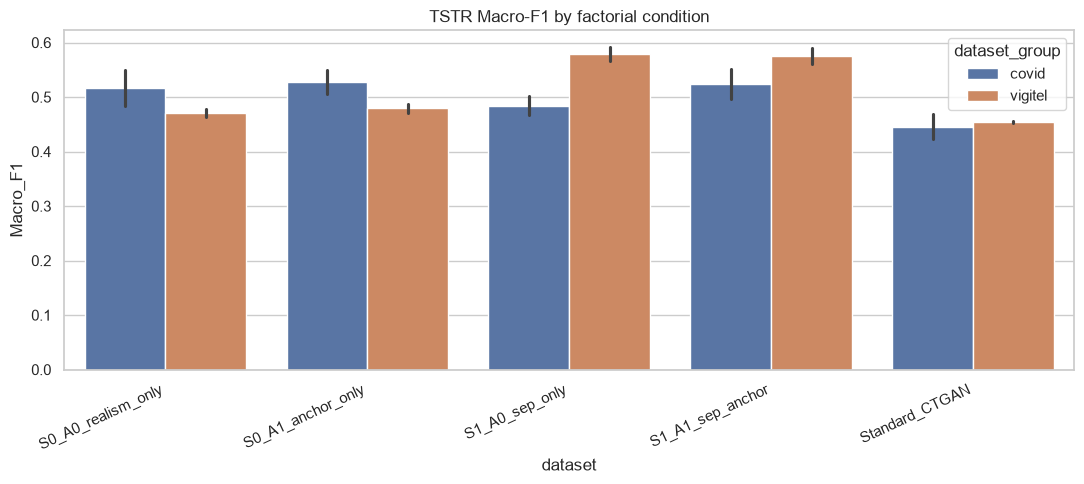

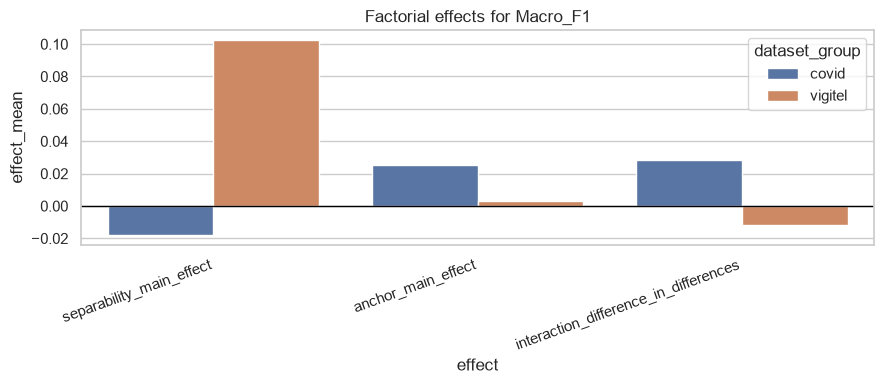

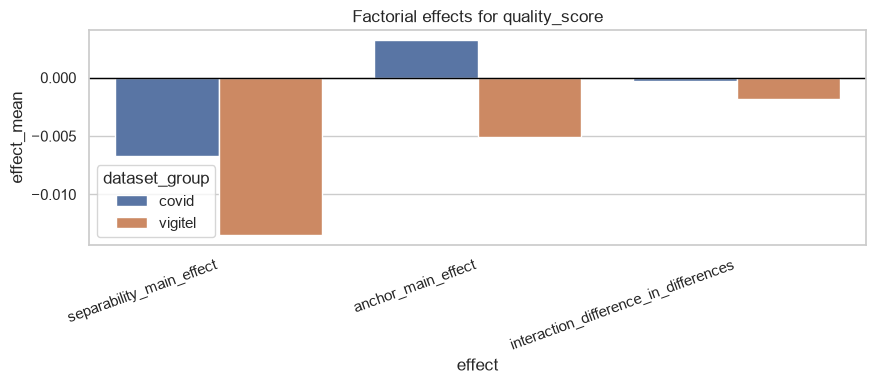

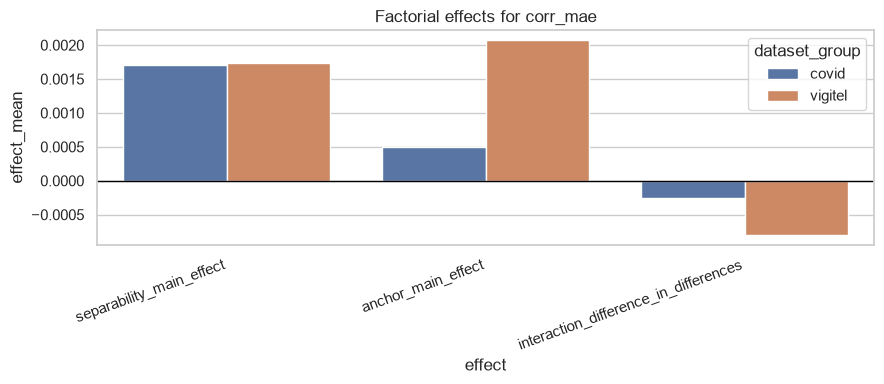

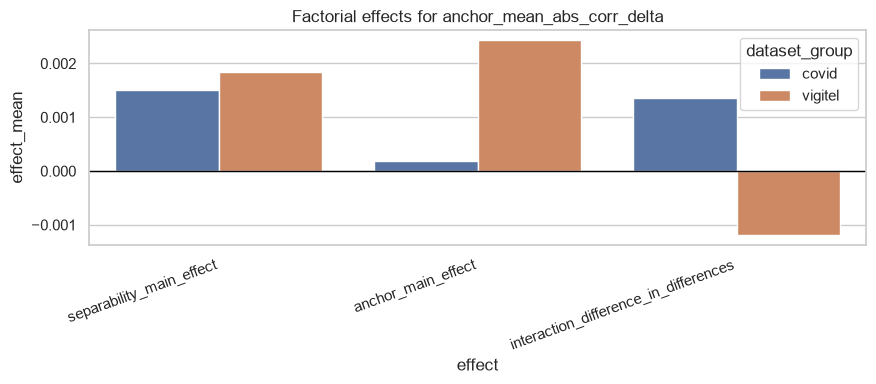

In [11]:
tstr_condition = performance_all[
    (performance_all["evaluation"] == "train_synthetic_test_real")
    & (performance_all["dataset"].isin([c["condition"] for c in FACTORIAL_CONDITIONS] + ["Real", "Standard_CTGAN"]))
].copy()

tstr_summary = summarize_mean_ci(
    tstr_condition.groupby(["dataset_group", "fold", "dataset"], as_index=False)["Macro_F1"].mean(),
    ["dataset_group", "dataset"],
    "Macro_F1",
)
tstr_summary.to_csv(TABLE_DIR / "tstr_macro_f1_condition_summary.csv", index=False)
display(tstr_summary.sort_values(["dataset_group", "Macro_F1_mean"], ascending=[True, False]))

plt.figure(figsize=(11, 5))
sns.barplot(
    data=tstr_condition.groupby(["dataset_group", "fold", "dataset"], as_index=False)["Macro_F1"].mean(),
    x="dataset",
    y="Macro_F1",
    hue="dataset_group",
    errorbar="se",
)
plt.xticks(rotation=25, ha="right")
plt.title("TSTR Macro-F1 by factorial condition")
plt.tight_layout()
plt.savefig(PLOT_DIR / "tstr_macro_f1_by_factorial_condition.png", dpi=200)
plt.show()

for metric in ["Macro_F1", "quality_score", "corr_mae", "anchor_mean_abs_corr_delta"]:
    sub = factorial_effect_summary[factorial_effect_summary["metric"] == metric]
    if sub.empty:
        continue
    plt.figure(figsize=(9, 4))
    sns.barplot(data=sub, x="effect", y="effect_mean", hue="dataset_group")
    plt.axhline(0, color="black", linewidth=1)
    plt.xticks(rotation=20, ha="right")
    plt.title(f"Factorial effects for {metric}")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"factorial_effects_{metric}.png", dpi=200)
    plt.show()

## 10. Spearman Correlation Matrix Comparison

In [12]:
def average_corr_matrices(corr_matrices, dataset_group, dataset_name):
    mats = []
    for (dg, fold, ds), mat in corr_matrices.items():
        if dg == dataset_group and ds == dataset_name:
            mats.append(mat)
    if not mats:
        return None
    base_cols = mats[0].columns
    arr = np.stack([m.reindex(index=base_cols, columns=base_cols).fillna(0).values for m in mats], axis=0)
    return pd.DataFrame(np.mean(arr, axis=0), index=base_cols, columns=base_cols)


for dataset_group, result in all_results.items():
    corr_mats = result["corr_matrices"]
    plot_conditions = ["Real_train", "Standard_CTGAN"] + [c["condition"] for c in FACTORIAL_CONDITIONS]
    avg_mats = {}
    for ds in plot_conditions:
        mat = average_corr_matrices(corr_mats, dataset_group, ds)
        if mat is not None:
            avg_mats[ds] = mat
            path = PLOT_DIR / f"{dataset_group}_mean_spearman_corr_{ds}.png"
            plt.figure(figsize=(max(8, 0.35 * len(mat)), max(6, 0.35 * len(mat))))
            sns.heatmap(mat, cmap="vlag", center=0, vmin=-1, vmax=1)
            plt.title(f"{dataset_group}: mean Spearman rho matrix - {ds}")
            plt.tight_layout()
            plt.savefig(path, dpi=200)
            plt.close()

    # Difference heatmaps against real training correlation structure.
    real_mat = avg_mats.get("Real_train")
    if real_mat is not None:
        for ds, mat in avg_mats.items():
            if ds == "Real_train":
                continue
            diff = mat.reindex(index=real_mat.index, columns=real_mat.columns).fillna(0) - real_mat
            plt.figure(figsize=(max(8, 0.35 * len(diff)), max(6, 0.35 * len(diff))))
            sns.heatmap(diff, cmap="vlag", center=0)
            plt.title(f"{dataset_group}: synthetic minus real Spearman rho - {ds}")
            plt.tight_layout()
            plt.savefig(PLOT_DIR / f"{dataset_group}_spearman_corr_delta_{ds}.png", dpi=200)
            plt.close()

print("Saved correlation heatmaps to", PLOT_DIR)

corr_summary = correlation_all.groupby(["dataset_group", "dataset"], as_index=False).agg(
    corr_similarity_mean=("corr_similarity", "mean"),
    corr_mae_mean=("corr_mae", "mean"),
    corr_frobenius_mean=("corr_frobenius", "mean"),
)
anchor_corr_summary = anchor_correlation_all.groupby(["dataset_group", "dataset", "anchor"], as_index=False).agg(
    anchor_mean_abs_corr_delta_mean=("anchor_mean_abs_corr_delta", "mean"),
    anchor_target_corr_delta_mean=("anchor_target_corr_delta", "mean"),
    anchor_target_corr_real_mean=("anchor_target_corr_real", "mean"),
    anchor_target_corr_synthetic_mean=("anchor_target_corr_synthetic", "mean"),
)
corr_summary.to_csv(TABLE_DIR / "spearman_correlation_similarity_summary.csv", index=False)
anchor_corr_summary.to_csv(TABLE_DIR / "anchor_correlation_summary.csv", index=False)

display(corr_summary.sort_values(["dataset_group", "corr_mae_mean"]))
display(anchor_corr_summary.sort_values(["dataset_group", "anchor", "anchor_mean_abs_corr_delta_mean"]).head(60))

Saved correlation heatmaps to sepaware_factorial_cv_outputs/plots


,dataset_group,dataset,corr_similarity_mean,corr_mae_mean,corr_frobenius_mean
0,covid,S0_A0_realism_only,0.341209,0.070525,4.354617
1,covid,S0_A1_anchor_only,0.323411,0.071147,4.338532
2,covid,S1_A0_sep_only,0.303916,0.072348,3.909516
3,covid,S1_A1_sep_anchor,0.292949,0.072722,3.955458
4,covid,Standard_CTGAN,-0.033571,0.086456,4.257131
5,vigitel,S0_A0_realism_only,0.728878,0.082694,1.814211
7,vigitel,S1_A0_sep_only,0.657181,0.084831,1.876925
6,vigitel,S0_A1_anchor_only,0.706993,0.085167,1.885372
8,vigitel,S1_A1_sep_anchor,0.628583,0.086501,1.925210
9,vigitel,Standard_CTGAN,0.103290,0.102791,2.400174


,dataset_group,dataset,anchor,anchor_mean_abs_corr_delta_mean,anchor_target_corr_delta_mean,anchor_target_corr_real_mean,anchor_target_corr_synthetic_mean
4,covid,S0_A1_anchor_only,comorb_cirrose,0.060651,0.153697,0.185078,0.031381
12,covid,S1_A1_sep_anchor,comorb_cirrose,0.061725,0.070025,0.185078,0.119208
0,covid,S0_A0_realism_only,comorb_cirrose,0.062315,0.199203,0.185078,-0.014124
8,covid,S1_A0_sep_only,comorb_cirrose,0.062331,0.127732,0.185078,0.057346
16,covid,Standard_CTGAN,comorb_cirrose,0.079107,0.211660,0.185078,-0.026582
9,covid,S1_A0_sep_only,idade,0.127419,0.133948,0.218512,0.341849
13,covid,S1_A1_sep_anchor,idade,0.127860,0.157623,0.218512,0.376136
5,covid,S0_A1_anchor_only,idade,0.127884,0.160486,0.218512,0.058027
1,covid,S0_A0_realism_only,idade,0.129377,0.183593,0.218512,0.034920
17,covid,Standard_CTGAN,idade,0.142444,0.239935,0.218512,-0.021423


## 11. Interpret Whether Anchor Matters and Why

In [13]:
def auto_interpret():
    lines = []
    macro = factorial_effect_summary[factorial_effect_summary["metric"] == "Macro_F1"]
    anchor_corr = factorial_effect_summary[factorial_effect_summary["metric"] == "anchor_mean_abs_corr_delta"]
    corr_mae = factorial_effect_summary[factorial_effect_summary["metric"] == "corr_mae"]

    for dg in sorted(factorial_effect_summary["dataset_group"].unique()):
        lines.append(f"### {dg.upper()}")
        m = macro[macro["dataset_group"] == dg]
        if not m.empty:
            sep_eff = m.loc[m["effect"] == "separability_main_effect", "effect_mean"].iloc[0]
            anc_eff = m.loc[m["effect"] == "anchor_main_effect", "effect_mean"].iloc[0]
            inter = m.loc[m["effect"] == "interaction_difference_in_differences", "effect_mean"].iloc[0]
            lines.append(f"- TSTR Macro-F1 separability main effect: {sep_eff:+.4f}.")
            lines.append(f"- TSTR Macro-F1 anchor main effect: {anc_eff:+.4f}.")
            lines.append(f"- TSTR Macro-F1 interaction effect: {inter:+.4f}.")
            if anc_eff > 0:
                lines.append("- Anchor improves downstream transfer on average in this factorial design.")
            else:
                lines.append("- Anchor does not improve downstream transfer on average in this factorial design.")
        ac = anchor_corr[anchor_corr["dataset_group"] == dg]
        if not ac.empty:
            anc_corr_eff = ac.loc[ac["effect"] == "anchor_main_effect", "effect_mean"].iloc[0]
            lines.append(f"- Anchor effect on anchor-correlation error: {anc_corr_eff:+.4f}. Negative means anchor reduced anchor-correlation distortion.")
        cm = corr_mae[corr_mae["dataset_group"] == dg]
        if not cm.empty:
            cm_eff = cm.loc[cm["effect"] == "anchor_main_effect", "effect_mean"].iloc[0]
            lines.append(f"- Anchor effect on full Spearman-correlation MAE: {cm_eff:+.4f}. Negative means better global correlation preservation.")
        lines.append("")

    text = "\n".join(lines)
    print(text)
    (TABLE_DIR / "automatic_factorial_interpretation.txt").write_text(text)


auto_interpret()

### COVID
- TSTR Macro-F1 separability main effect: -0.0180.
- TSTR Macro-F1 anchor main effect: +0.0254.
- TSTR Macro-F1 interaction effect: +0.0282.
- Anchor improves downstream transfer on average in this factorial design.
- Anchor effect on anchor-correlation error: +0.0002. Negative means anchor reduced anchor-correlation distortion.
- Anchor effect on full Spearman-correlation MAE: +0.0005. Negative means better global correlation preservation.

### VIGITEL
- TSTR Macro-F1 separability main effect: +0.1024.
- TSTR Macro-F1 anchor main effect: +0.0030.
- TSTR Macro-F1 interaction effect: -0.0120.
- Anchor improves downstream transfer on average in this factorial design.
- Anchor effect on anchor-correlation error: +0.0024. Negative means anchor reduced anchor-correlation distortion.
- Anchor effect on full Spearman-correlation MAE: +0.0021. Negative means better global correlation preservation.



## 12. Replicated $2^k r$ model and assumptions

For dataset $d$, fold/block $j$, separability level $A_i\in\{-1,+1\}$ and anchor
level $B_i\in\{-1,+1\}$, the blocked replicated-factorial model is

$$y_{ij}=\mu+\beta_A A_i+\beta_B B_i+\beta_{AB}A_iB_i+\gamma_j+\varepsilon_{ij}.$$

Here $k=2$, $2^k=4$ treatment combinations and $r=5$ fold replications, giving
$N=20$ SepAware observations per dataset for each response. Fold is treated as a
block because every condition is evaluated on the same held-out fold.

Assumptions checked below:

1. approximate residual independence: held-out test folds are disjoint, but the
   fold-training sets overlap, so ordinary $F$ tests are descriptive rather than
   exact independent-replication tests,
2. normally distributed model errors,
3. constant error variance across the four treatment combinations,
4. an additive linear factorial structure after including the $A\times B$
   interaction and fold block,
5. no leakage: synthesis and selection occur using fold-training data only.

The percentage attributed to **error should preferably be modest**, because that
means the controlled factors explain a useful part of variation. It need not be
near zero: a suspiciously tiny residual can indicate pseudoreplication, leakage,
or an overfitted model. With only five folds, diagnostic tests also have low power,
so plots and effect uncertainty matter more than a pass/fail p-value.


In [14]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import levene, shapiro

FACTOR_LABELS = {
    "S0_A0_realism_only": "(1) realism only",
    "S1_A0_sep_only": "A separability",
    "S0_A1_anchor_only": "B anchor",
    "S1_A1_sep_anchor": "AB separability + anchor",
}

def factorial_frame(metric_source="performance", metric="Macro_F1"):
    out = build_condition_outcome_table(metric_source, metric).merge(condition_map, on="dataset")
    out["A_sep"] = out["sep_on"].map({0: -1, 1: 1})
    out["B_anchor"] = out["anchor_on"].map({0: -1, 1: 1})
    out["AB"] = out["A_sep"] * out["B_anchor"]
    out["condition_label"] = out["dataset"].map(FACTOR_LABELS)
    out["fold"] = out["fold"].astype(str)
    out["response"] = pd.to_numeric(out[metric], errors="coerce")
    out["log_response"] = np.log(out["response"].clip(lower=np.finfo(float).eps))
    return out.dropna(subset=["response"])

factorial_macro_f1 = factorial_frame("performance", "Macro_F1")
display(factorial_macro_f1[["dataset_group", "fold", "condition_label", "A_sep", "B_anchor", "response", "log_response"]])
factorial_macro_f1.to_csv(TABLE_DIR / "actual_2k_r_macro_f1_raw_and_log.csv", index=False)


,dataset_group,fold,condition_label,A_sep,B_anchor,response,log_response
0,covid,1,(1) realism only,-1,-1,0.529825,-0.635209
1,covid,1,B anchor,-1,1,0.568085,-0.565484
2,covid,1,A separability,1,-1,0.458816,-0.779106
3,covid,1,AB separability + anchor,1,1,0.551678,-0.594790
4,covid,2,(1) realism only,-1,-1,0.441075,-0.818539
5,covid,2,B anchor,-1,1,0.529825,-0.635209
6,covid,2,A separability,1,-1,0.438428,-0.824559
7,covid,2,AB separability + anchor,1,1,0.470654,-0.753632
8,covid,3,(1) realism only,-1,-1,0.515147,-0.663303
9,covid,3,B anchor,-1,1,0.560407,-0.579092


## 13. Actual $2^k r$ numbers and raw/log-scale effects

The first table is the complete $4\times5$ response matrix. The second reports
the standard factorial contrasts. A main effect is the mean response at the high
factor level minus the mean response at the low level. The interaction is the
difference-in-differences. Log-scale effects can be converted to approximate
multiplicative percentage changes using $100(\exp(effect)-1)$.


In [15]:
actual_response_tables = {}
effect_scale_rows = []
for dg, g in factorial_macro_f1.groupby("dataset_group"):
    actual = g.pivot(index="fold", columns="condition_label", values="response")
    actual_response_tables[dg] = actual
    print(f"{dg.upper()} — actual fold-level Macro-F1")
    display(actual.style.format("{:.4f}"))

    for scale, col in [("raw", "response"), ("natural_log", "log_response")]:
        p = g.pivot_table(index="fold", columns=["sep_on", "anchor_on"], values=col)
        fold_effects = pd.DataFrame({
            "separability": ((p[(1, 0)] + p[(1, 1)]) - (p[(0, 0)] + p[(0, 1)])) / 2,
            "anchor": ((p[(0, 1)] + p[(1, 1)]) - (p[(0, 0)] + p[(1, 0)])) / 2,
            "interaction": (p[(1, 1)] - p[(1, 0)]) - (p[(0, 1)] - p[(0, 0)]),
        })
        for effect_name in fold_effects:
            value = fold_effects[effect_name].mean()
            effect_scale_rows.append({
                "dataset_group": dg,
                "scale": scale,
                "effect": effect_name,
                "estimate": value,
                "multiplicative_percent_if_log": 100 * np.expm1(value) if scale == "natural_log" else np.nan,
            })

effect_scale_table = pd.DataFrame(effect_scale_rows)
display(effect_scale_table.style.format({"estimate": "{:+.5f}", "multiplicative_percent_if_log": "{:+.2f}%"}))
effect_scale_table.to_csv(TABLE_DIR / "factorial_effects_raw_and_log_scale.csv", index=False)


COVID — actual fold-level Macro-F1


condition_label,(1) realism only,A separability,AB separability + anchor,B anchor
fold,,,,
1,0.5298,0.4588,0.5517,0.5681
2,0.4411,0.4384,0.4707,0.5298
3,0.5151,0.5375,0.4729,0.5604
4,0.4644,0.4920,0.5074,0.4417
5,0.6313,0.4944,0.6161,0.5384


VIGITEL — actual fold-level Macro-F1


condition_label,(1) realism only,A separability,AB separability + anchor,B anchor
fold,,,,
1,0.4984,0.5996,0.6046,0.5014
2,0.4667,0.5952,0.5983,0.4777
3,0.4734,0.6054,0.5932,0.4965
4,0.4534,0.5597,0.5558,0.4591
5,0.4605,0.5346,0.5278,0.4628


,dataset_group,scale,effect,estimate,multiplicative_percent_if_log
0,covid,raw,separability,-0.01803,+nan%
1,covid,raw,anchor,+0.02543,+nan%
2,covid,raw,interaction,+0.02816,+nan%
3,covid,natural_log,separability,-0.03382,-3.33%
4,covid,natural_log,anchor,+0.05062,+5.19%
5,covid,natural_log,interaction,+0.04999,+5.13%
6,vigitel,raw,separability,+0.10241,+nan%
7,vigitel,raw,anchor,+0.00302,+nan%
8,vigitel,raw,interaction,-0.01198,+nan%
9,vigitel,natural_log,separability,+0.19462,+21.49%


## 14. ANOVA and percentage of variation explained

Two percentages are shown:

- **% of total SS:** contribution relative to all variation, including folds.
- **% of experimental SS:** separability, anchor, interaction and residual error
  renormalized to 100% after the nuisance fold/block variation is removed. This is
  the four-part decomposition requested for the experiment.

Because the design is balanced and orthogonal, sums of squares for the two factors
and their interaction have a direct factorial interpretation. Fold is included as
a block to avoid incorrectly treating between-fold difficulty as pure error.


In [16]:
def replicated_factorial_anova(frame, response_col="response"):
    rows, models = [], {}
    for dg, g in frame.groupby("dataset_group"):
        model = smf.ols(f"{response_col} ~ A_sep * B_anchor + C(fold)", data=g).fit()
        aov = anova_lm(model, typ=2).reset_index().rename(columns={"index": "source", "sum_sq": "SS", "df": "DF", "F": "F_value", "PR(>F)": "p_value"})
        aov["source"] = aov["source"].replace({
            "A_sep": "Separability",
            "B_anchor": "Anchor",
            "A_sep:B_anchor": "Separability × Anchor",
            "C(fold)": "Fold (block)",
            "Residual": "Error",
        })
        total_ss = aov["SS"].sum()
        experimental_sources = ["Separability", "Anchor", "Separability × Anchor", "Error"]
        experimental_ss = aov.loc[aov["source"].isin(experimental_sources), "SS"].sum()
        aov["percent_total_SS"] = 100 * aov["SS"] / total_ss
        aov["percent_experimental_SS"] = np.where(
            aov["source"].isin(experimental_sources), 100 * aov["SS"] / experimental_ss, np.nan
        )
        aov.insert(0, "dataset_group", dg)
        aov.insert(1, "scale", response_col.replace("_response", ""))
        rows.append(aov)
        models[(dg, response_col)] = model
    return pd.concat(rows, ignore_index=True), models

anova_raw, models_raw = replicated_factorial_anova(factorial_macro_f1, "response")
anova_log, models_log = replicated_factorial_anova(factorial_macro_f1, "log_response")
anova_all = pd.concat([anova_raw, anova_log], ignore_index=True)

for (dg, scale), tab in anova_all.groupby(["dataset_group", "scale"]):
    print(f"{dg.upper()} — {scale} scale")
    display(tab.style.format({"SS": "{:.7f}", "F_value": "{:.3f}", "p_value": "{:.4f}", "percent_total_SS": "{:.2f}%", "percent_experimental_SS": "{:.2f}%"}, na_rep="—"))

anova_all.to_csv(TABLE_DIR / "replicated_factorial_anova_variation_percentages.csv", index=False)


COVID — log scale


,dataset_group,scale,source,SS,DF,F_value,p_value,percent_total_SS,percent_experimental_SS
10,covid,log,Fold (block),0.0984847,4.000000,3.094,0.0576,45.67%,—
11,covid,log,Separability,0.0057199,1.000000,0.719,0.4132,2.65%,4.88%
12,covid,log,Anchor,0.0128098,1.000000,1.610,0.2286,5.94%,10.93%
13,covid,log,Separability × Anchor,0.0031232,1.000000,0.392,0.5428,1.45%,2.67%
14,covid,log,Error,0.0955043,12.000000,—,—,44.29%,81.52%


COVID — response scale


,dataset_group,scale,source,SS,DF,F_value,p_value,percent_total_SS,percent_experimental_SS
0,covid,response,Fold (block),0.0268647,4.000000,3.120,0.0563,45.88%,—
1,covid,response,Separability,0.0016258,1.000000,0.755,0.4019,2.78%,5.13%
2,covid,response,Anchor,0.0032336,1.000000,1.502,0.2439,5.52%,10.21%
3,covid,response,Separability × Anchor,0.0009914,1.000000,0.461,0.5103,1.69%,3.13%
4,covid,response,Error,0.0258334,12.000000,—,—,44.12%,81.53%


VIGITEL — log scale


,dataset_group,scale,source,SS,DF,F_value,p_value,percent_total_SS,percent_experimental_SS
15,vigitel,log,Fold (block),0.0308060,4.000000,15.832,0.0001,13.57%,—
16,vigitel,log,Separability,0.1893876,1.000000,389.325,0.0000,83.43%,96.53%
17,vigitel,log,Anchor,0.0002282,1.000000,0.469,0.5064,0.10%,0.12%
18,vigitel,log,Separability × Anchor,0.0007326,1.000000,1.506,0.2433,0.32%,0.37%
19,vigitel,log,Error,0.0058374,12.000000,—,—,2.57%,2.98%


VIGITEL — response scale


,dataset_group,scale,source,SS,DF,F_value,p_value,percent_total_SS,percent_experimental_SS
5,vigitel,response,Fold (block),0.0087669,4.000000,13.413,0.0002,13.83%,—
6,vigitel,response,Separability,0.0524374,1.000000,320.899,0.0000,82.72%,96.00%
7,vigitel,response,Anchor,0.0000456,1.000000,0.279,0.6069,0.07%,0.08%
8,vigitel,response,Separability × Anchor,0.0001793,1.000000,1.098,0.3154,0.28%,0.33%
9,vigitel,response,Error,0.0019609,12.000000,—,—,3.09%,3.59%


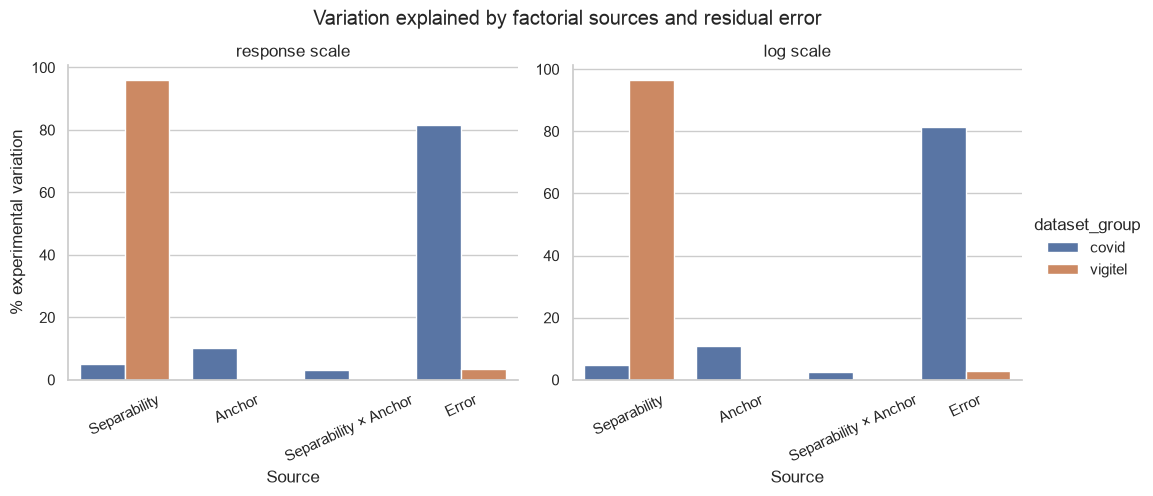

In [17]:
plot_pct = anova_all[
    (anova_all["scale"].isin(["response", "log"]))
    & anova_all["source"].isin(["Separability", "Anchor", "Separability × Anchor", "Error"])
].copy()

g = sns.catplot(
    data=plot_pct,
    x="source", y="percent_experimental_SS", hue="dataset_group", col="scale",
    kind="bar", height=4.2, aspect=1.25, sharey=False,
)
g.set_axis_labels("Source", "% experimental variation")
g.set_titles("{col_name} scale")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=25)
    ax.set_ylim(bottom=0)
g.fig.suptitle("Variation explained by factorial sources and residual error", y=1.04)
plt.savefig(PLOT_DIR / "factorial_variation_percent_raw_log.png", dpi=200, bbox_inches="tight")
plt.show()


## 15. Residual diagnostics: QQ plots, equal variance and normality

- A QQ plot close to a straight line supports residual normality.
- Shapiro–Wilk tests residual normality; a large p-value means insufficient
  evidence against normality, not proof of normality.
- Levene's test compares residual variance across the four conditions.
- Breusch–Pagan tests whether residual variance changes with fitted values/design.
- Residual-versus-fitted plots should show an unstructured cloud with similar
  vertical spread throughout.

Use $\alpha=0.05$ as a descriptive flag, while remembering that $N=20$ provides
limited diagnostic-test power.


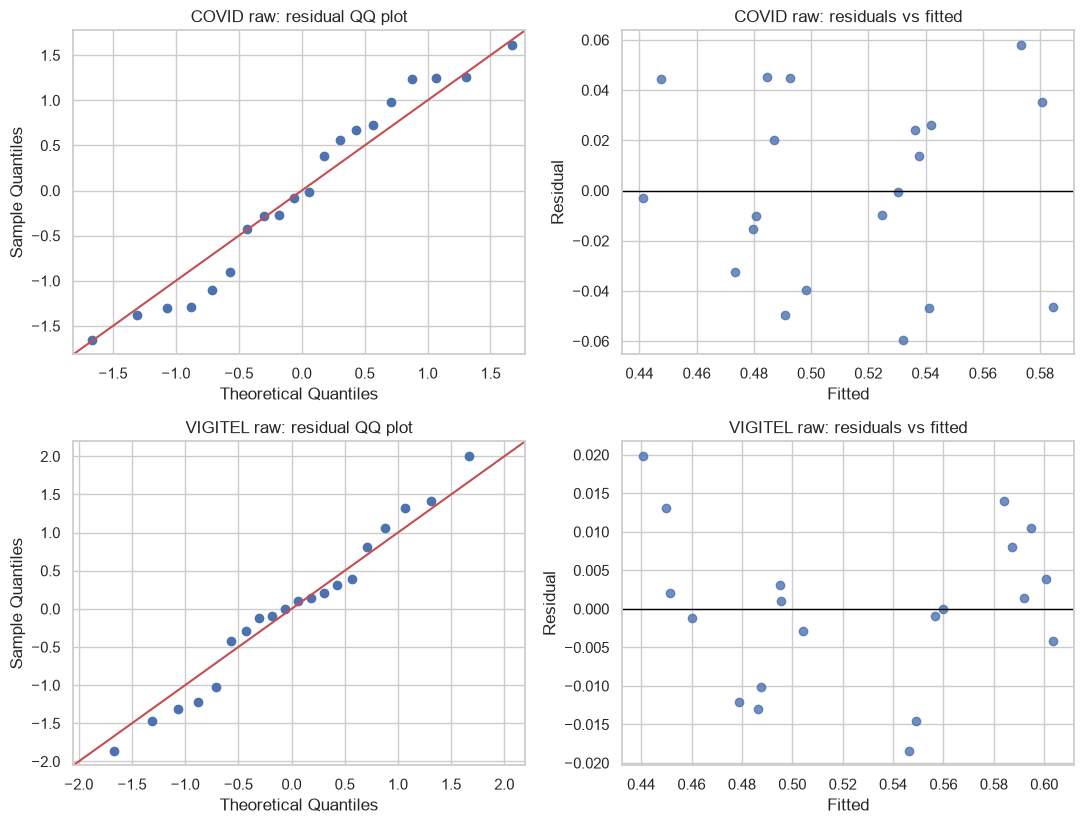

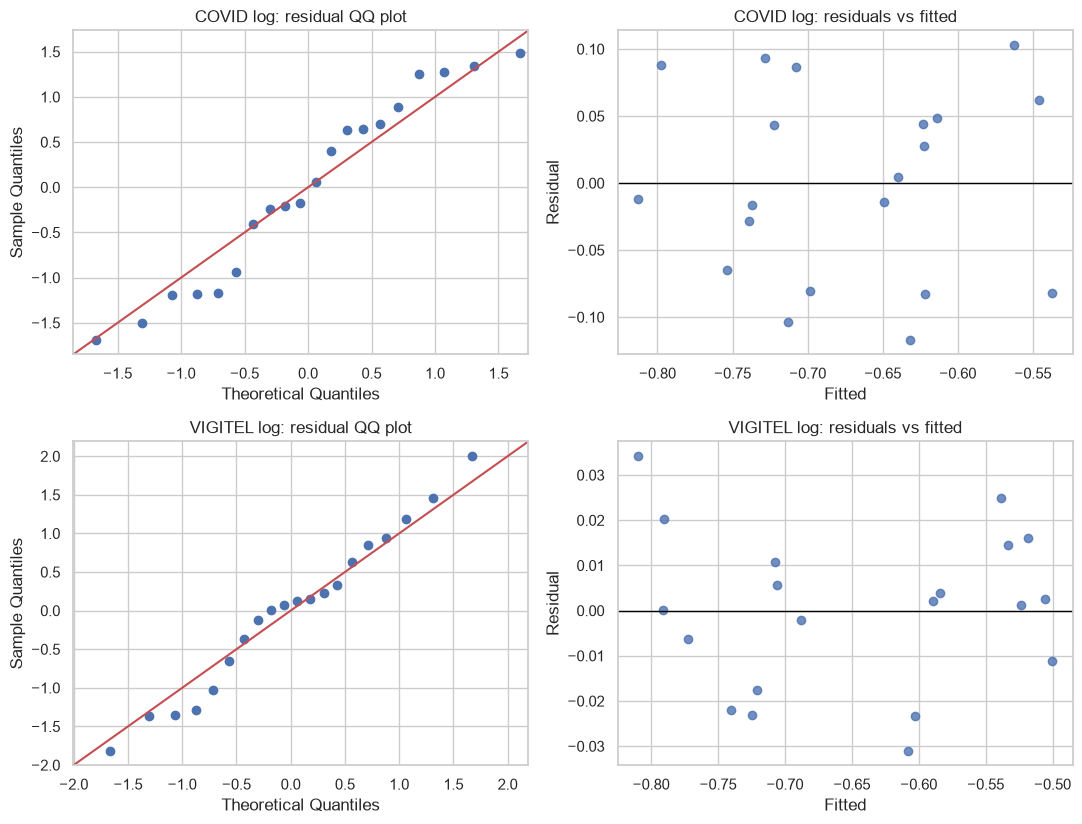

,dataset_group,scale,n,shapiro_W,shapiro_p,levene_stat,levene_p,breusch_pagan_LM,breusch_pagan_p,normality_flag_p_lt_0_05,heteroscedasticity_flag_p_lt_0_05
0,covid,raw,20,0.9405,0.2446,0.2773,0.8409,6.8796,0.4415,False,False
1,vigitel,raw,20,0.9751,0.8564,0.2768,0.8413,16.8211,0.0186,False,True
2,covid,log,20,0.9362,0.2031,0.3107,0.8173,5.1352,0.6435,False,False
3,vigitel,log,20,0.9754,0.8625,0.4125,0.7463,16.1557,0.0237,False,True


In [18]:
diagnostic_rows = []
for scale, model_dict in [("raw", models_raw), ("log", models_log)]:
    fig, axes = plt.subplots(len(model_dict), 2, figsize=(11, 4.2 * len(model_dict)), squeeze=False)
    for row, ((dg, _), model) in enumerate(model_dict.items()):
        resid = np.asarray(model.resid)
        fitted = np.asarray(model.fittedvalues)
        sm.qqplot(resid, line="45", fit=True, ax=axes[row, 0])
        axes[row, 0].set_title(f"{dg.upper()} {scale}: residual QQ plot")
        axes[row, 1].scatter(fitted, resid, alpha=0.8)
        axes[row, 1].axhline(0, color="black", linewidth=1)
        axes[row, 1].set(title=f"{dg.upper()} {scale}: residuals vs fitted", xlabel="Fitted", ylabel="Residual")

        g = factorial_macro_f1[factorial_macro_f1["dataset_group"] == dg].copy()
        g["model_residual"] = resid
        groups = [x["model_residual"].to_numpy() for _, x in g.groupby("condition_label")]
        sh_stat, sh_p = shapiro(resid)
        lev_stat, lev_p = levene(*groups, center="median")
        bp_lm, bp_lm_p, bp_f, bp_f_p = het_breuschpagan(resid, model.model.exog)
        diagnostic_rows.append({
            "dataset_group": dg, "scale": scale, "n": len(resid),
            "shapiro_W": sh_stat, "shapiro_p": sh_p,
            "levene_stat": lev_stat, "levene_p": lev_p,
            "breusch_pagan_LM": bp_lm, "breusch_pagan_p": bp_lm_p,
            "normality_flag_p_lt_0_05": sh_p < 0.05,
            "heteroscedasticity_flag_p_lt_0_05": (lev_p < 0.05) or (bp_lm_p < 0.05),
        })
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"residual_diagnostics_{scale}.png", dpi=200, bbox_inches="tight")
    plt.show()

diagnostics = pd.DataFrame(diagnostic_rows)
display(diagnostics.style.format({"shapiro_W": "{:.4f}", "shapiro_p": "{:.4f}", "levene_stat": "{:.4f}", "levene_p": "{:.4f}", "breusch_pagan_LM": "{:.4f}", "breusch_pagan_p": "{:.4f}"}))
diagnostics.to_csv(TABLE_DIR / "factorial_assumption_diagnostics.csv", index=False)


## 16. Attribute-to-attribute correlation percentages

For interpretability, Spearman $\rho$ is shown as a signed percentage
$100\rho$. For example, $-42\%$ means $\rho=-0.42$; it is **not** “42% variance
explained.” If a variance-like interpretation is needed, the table also includes
$100\rho^2$, but this remains a bivariate descriptive measure rather than causal
variance explained.

The complete long table is saved to CSV because an $m\times m$ matrix becomes too
wide to read comfortably in a notebook.


In [19]:
correlation_percent_rows = []
for dataset_group, result in all_results.items():
    corr_mats = result["corr_matrices"]
    names = ["Real_train", "Standard_CTGAN"] + [c["condition"] for c in FACTORIAL_CONDITIONS]
    for dataset_name in names:
        mat = average_corr_matrices(corr_mats, dataset_group, dataset_name)
        if mat is None:
            continue
        for i, attr_1 in enumerate(mat.index):
            for j, attr_2 in enumerate(mat.columns):
                if j <= i:
                    continue
                rho = float(mat.iloc[i, j])
                correlation_percent_rows.append({
                    "dataset_group": dataset_group,
                    "condition": dataset_name,
                    "attribute_1": attr_1,
                    "attribute_2": attr_2,
                    "spearman_rho": rho,
                    "signed_correlation_percent": 100 * rho,
                    "absolute_correlation_percent": 100 * abs(rho),
                    "rho_squared_percent": 100 * rho**2,
                })

correlation_percent_long = pd.DataFrame(correlation_percent_rows)
correlation_percent_long.to_csv(TABLE_DIR / "attribute_pair_correlation_percentages.csv", index=False)

for dg in correlation_percent_long["dataset_group"].unique():
    real_pairs = correlation_percent_long.query("dataset_group == @dg and condition == 'Real_train'")
    print(f"{dg.upper()} — strongest real-data attribute correlations")
    display(real_pairs.nlargest(25, "absolute_correlation_percent").style.format({
        "spearman_rho": "{:+.3f}", "signed_correlation_percent": "{:+.1f}%",
        "absolute_correlation_percent": "{:.1f}%", "rho_squared_percent": "{:.1f}%",
    }))

print("Complete pairwise table saved to:", TABLE_DIR / "attribute_pair_correlation_percentages.csv")


COVID — strongest real-data attribute correlations


,dataset_group,condition,attribute_1,attribute_2,spearman_rho,signed_correlation_percent,absolute_correlation_percent,rho_squared_percent
441,covid,Real_train,n_comorbidades,comorb_hipertensao,+0.686,+68.6%,68.6%,47.1%
448,covid,Real_train,n_comorbidades,comorb_dm,+0.627,+62.7%,62.7%,39.3%
17,covid,Real_train,idade,n_comorbidades,+0.465,+46.5%,46.5%,21.6%
18,covid,Real_train,idade,comorb_hipertensao,+0.463,+46.3%,46.3%,21.4%
150,covid,Real_train,motivo_cancer,comorb_cancer,+0.452,+45.2%,45.2%,20.4%
443,covid,Real_train,n_comorbidades,comorb_dac,+0.443,+44.3%,44.3%,19.6%
442,covid,Real_train,n_comorbidades,comorb_ic,+0.395,+39.5%,39.5%,15.6%
462,covid,Real_train,comorb_hipertensao,comorb_dm,+0.301,+30.1%,30.1%,9.1%
33,covid,Real_train,sexo,etilismo,-0.299,-29.9%,29.9%,9.0%
444,covid,Real_train,n_comorbidades,comorb_fibrilacao,+0.299,+29.9%,29.9%,8.9%


VIGITEL — strongest real-data attribute correlations


,dataset_group,condition,attribute_1,attribute_2,spearman_rho,signed_correlation_percent,absolute_correlation_percent,rho_squared_percent
3471,vigitel,Real_train,doces5,lanche_7,+0.729,+72.9%,72.9%,53.2%
3431,vigitel,Real_train,ativo_livre,ati_livre,+0.555,+55.5%,55.5%,30.8%
3416,vigitel,Real_train,exfuma,gordura,+0.536,+53.6%,53.6%,28.7%
3373,vigitel,Real_train,age,hart,+0.428,+42.8%,42.8%,18.4%
3472,vigitel,Real_train,doces5,gordura,+0.339,+33.9%,33.9%,11.5%
3421,vigitel,Real_train,inativo,ati_livre,-0.323,-32.3%,32.3%,10.4%
3450,vigitel,Real_train,diab,hart,+0.287,+28.7%,28.7%,8.2%
3415,vigitel,Real_train,exfuma,lanche_7,+0.275,+27.5%,27.5%,7.6%
3436,vigitel,Real_train,ativo_livre,lanche_7,+0.267,+26.7%,26.7%,7.1%
3435,vigitel,Real_train,ativo_livre,doces5,+0.266,+26.6%,26.6%,7.1%


Complete pairwise table saved to: sepaware_factorial_cv_outputs/tables/attribute_pair_correlation_percentages.csv


In [20]:
# Compact signed-percentage matrices for the real data and all four conditions.
for dataset_group, result in all_results.items():
    names = ["Real_train"] + [c["condition"] for c in FACTORIAL_CONDITIONS]
    for dataset_name in names:
        mat = average_corr_matrices(result["corr_matrices"], dataset_group, dataset_name)
        if mat is None:
            continue
        pct = 100 * mat
        pct.to_csv(TABLE_DIR / f"{dataset_group}_{dataset_name}_signed_correlation_percent_matrix.csv")
        if dataset_name == "Real_train":
            print(f"{dataset_group.upper()} — real-data signed correlation percentages")
            display(pct.round(1))


COVID — real-data signed correlation percentages


,idade,sexo,etilismo,tabagismo,motivo_cancer,motivo_msk,motivo_digestivo2,motivo_cardio2,motivo_procedimentos2,motivo_lesao2,...,comorb_dpoc,comorb_asma,comorb_dm,comorb_obesidade,comorb_drc,comorb_cancer,comorb_reumatologica,comorb_cirrose,comorb_hiv,obito
idade,100.0,15.7,-22.4,10.6,-10.2,2.6,2.8,22.8,-7.2,-4.1,...,23.1,2.0,21.3,-6.1,6.9,4.2,3.5,-1.8,-19.1,21.9
sexo,15.7,100.0,-29.9,-9.4,6.5,-6.5,-1.0,10.5,9.3,-5.8,...,14.7,14.5,4.5,7.9,1.4,13.6,1.7,-9.9,-1.7,1.7
etilismo,-22.4,-29.9,100.0,19.0,-8.4,5.9,8.8,-7.8,-3.2,12.9,...,1.4,-7.8,-15.9,-6.7,-7.1,-12.7,-6.1,14.6,5.6,1.0
tabagismo,10.6,-9.4,19.0,100.0,-1.7,-5.1,-3.0,10.7,-2.6,-6.0,...,18.5,2.3,-4.5,-1.3,4.8,2.6,-3.4,4.5,6.6,14.1
motivo_cancer,-10.2,6.5,-8.4,-1.7,100.0,-1.8,-10.5,-13.1,-6.9,-9.5,...,0.0,-3.7,-11.2,-6.2,-0.9,45.2,-4.8,-4.6,-4.8,-1.4
motivo_msk,2.6,-6.5,5.9,-5.1,-1.8,100.0,-3.4,-4.2,-2.2,-3.1,...,15.0,-1.2,2.7,-2.0,-2.9,8.5,-1.5,-1.5,-1.5,-4.4
motivo_digestivo2,2.8,-1.0,8.8,-3.0,-10.5,-3.4,100.0,-20.4,-12.8,-17.5,...,-10.5,3.9,0.1,-4.6,-6.5,7.0,-0.5,26.4,-0.4,1.1
motivo_cardio2,22.8,10.5,-7.8,10.7,-13.1,-4.2,-20.4,100.0,-10.8,-20.0,...,21.3,9.9,3.1,-2.6,13.8,-17.2,3.5,-10.6,-7.5,-2.3
motivo_procedimentos2,-7.2,9.3,-3.2,-2.6,-6.9,-2.2,-12.8,-10.8,100.0,-11.6,...,3.0,-4.5,3.2,1.6,2.7,8.3,-0.1,0.4,-0.3,-3.8
motivo_lesao2,-4.1,-5.8,12.9,-6.0,-9.5,-3.1,-17.5,-20.0,-11.6,100.0,...,-1.9,-6.2,-9.8,3.9,-12.3,-13.0,-3.5,-7.7,-3.7,-4.9


VIGITEL — real-data signed correlation percentages


,age,sex,fumante,exfuma,inativo,ativo_livre,ati_livre,diab,hart,dislipidemia,doces5,lanche_7,gordura,flvreg,years_schooling,obesity
age,100.0,7.6,1.6,-0.5,18.3,3.7,-10.5,26.1,42.8,16.1,6.1,10.7,-21.5,15.6,-23.2,10.6
sex,7.6,100.0,-7.9,-9.1,1.6,-5.4,-10.4,3.1,5.8,3.6,0.0,0.6,-11.7,10.4,0.4,-2.4
fumante,1.6,-7.9,100.0,-7.0,-1.3,-6.4,-5.0,-2.0,-2.8,-3.5,-4.2,-3.5,5.9,-6.2,-7.9,-5.0
exfuma,-0.5,-9.1,-7.0,100.0,-7.3,-16.1,0.2,0.6,0.4,19.9,25.7,27.5,53.6,-1.5,-6.8,0.3
inativo,18.3,1.6,-1.3,-7.3,100.0,10.2,-32.3,7.8,10.7,0.8,11.6,13.2,-9.5,-3.4,-4.1,5.0
ativo_livre,3.7,-5.4,-6.4,-16.1,10.2,100.0,55.5,2.6,-1.2,-8.3,26.6,26.7,-21.9,10.8,13.5,0.6
ati_livre,-10.5,-10.4,-5.0,0.2,-32.3,55.5,100.0,-4.0,-8.1,-1.0,2.4,1.8,-0.2,14.3,17.6,-6.7
diab,26.1,3.1,-2.0,0.6,7.8,2.6,-4.0,100.0,28.7,12.3,3.2,4.9,-7.3,1.3,-12.4,12.3
hart,42.8,5.8,-2.8,0.4,10.7,-1.2,-8.1,28.7,100.0,16.1,2.8,3.2,-8.4,2.8,-19.4,19.1
dislipidemia,16.1,3.6,-3.5,19.9,0.8,-8.3,-1.0,12.3,16.1,100.0,19.5,19.4,16.0,3.2,-2.7,4.3


## 17. Decision summary

After the full run (`SMOKE_TEST = False`), interpret in this order:

1. Confirm all 20 factorial observations per dataset are present.
2. Compare raw and log diagnostics; prefer the scale with more stable variance and
   approximately straight QQ behavior.
3. Report factorial effect estimates with direction and magnitude.
4. Report the experimental variation percentages for separability, anchor,
   interaction and error.
5. Treat a large error percentage as evidence that fold-to-fold/random training
   variation dominates; do not conceal it.
6. Treat a very small error percentage cautiously and audit leakage, independence,
   and whether folds are genuine replications.
7. Use correlation percentages descriptively; they do not replace the ANOVA
   variation decomposition and do not establish causality.


In [21]:
required_outputs = [
    TABLE_DIR / "actual_2k_r_macro_f1_raw_and_log.csv",
    TABLE_DIR / "factorial_effects_raw_and_log_scale.csv",
    TABLE_DIR / "replicated_factorial_anova_variation_percentages.csv",
    TABLE_DIR / "factorial_assumption_diagnostics.csv",
    TABLE_DIR / "attribute_pair_correlation_percentages.csv",
]
output_manifest = pd.DataFrame({"path": required_outputs, "exists": [p.exists() for p in required_outputs]})
display(output_manifest)
assert output_manifest["exists"].all(), "One or more expected output tables were not created."
print("Experiment complete. Outputs:", OUTPUT_DIR.resolve())


,path,exists
0,sepaware_factorial_cv_outputs/tables/actual_2k...,True
1,sepaware_factorial_cv_outputs/tables/factorial...,True
2,sepaware_factorial_cv_outputs/tables/replicate...,True
3,sepaware_factorial_cv_outputs/tables/factorial...,True
4,sepaware_factorial_cv_outputs/tables/attribute...,True


Experiment complete. Outputs: <SEPAWARE_DATA_ROOT>/sepaware_factorial_cv_outputs


## 18. How to Defend the Design

Use this language in the methodology:

> We converted SepAware into a controlled factorial experiment. Separability and anchor preservation were treated as two binary experimental factors, giving four synthetic-selection regimes per fold. Repeating the experiment over five stratified folds let us estimate main effects and interaction effects rather than relying on one generated dataset.

The most important equations are:

\[
S(x) = R(x) + \lambda_{sep} Sep(x) + \lambda_{anchor} A(x)
\]

For outcome \(Y\), where \(Y_{00}\) is realism only, \(Y_{10}\) is separability only, \(Y_{01}\) is anchor only, and \(Y_{11}\) is separability plus anchor:

\[
E_{sep} = \frac{Y_{10} + Y_{11}}{2} - \frac{Y_{00} + Y_{01}}{2}
\]

\[
E_{anchor} = \frac{Y_{01} + Y_{11}}{2} - \frac{Y_{00} + Y_{10}}{2}
\]

\[
E_{interaction} = (Y_{11} - Y_{10}) - (Y_{01} - Y_{00})
\]

If anchor helps COVID but not Vigitel, the explanation should come from the combination of:

- anchor main effect on TSTR Macro-F1,
- anchor main effect on anchor-correlation error,
- preservation or distortion of target-anchor Spearman correlations,
- interaction between separability and anchor preservation.